# Predicting Corporate Bankruptcy from Financial Statements

**Author:** Mauro Reverberi

**Program:** MSc AI, Udacity Institute of AI & Technology / Woolf

**Project:** Capstone Project 3, Machine Learning Foundations

**Dataset:** Polish Companies Bankruptcy Data, UCI Machine Learning Repository (dataset 365), license CC BY 4.0:
https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data

In this notebook I train a model that predicts from one snapshot of financial
indicators whether a company will go bankrupt within the next three
years. The input is 64 financial indicators per company, most of them from a
single annual statement and a few spanning several years. The output is a
bankruptcy risk score.

**Research question:** How well can supervised machine learning predict, from
one snapshot of financial indicators, whether a company will go bankrupt within three
years, and how should the model scores be turned into decisions when
bankruptcies are rare?

I picked this problem because it connects to my earlier capstone projects. In Project 1 I
built a cleaned dataset of Swiss legal entities from the GLEIF register, in
Project 2 I analyzed new company registrations from the Swiss commercial gazette. A
later capstone project will build a due diligence agent that looks up a
company and assesses it. Such an agent needs exactly the decision modeled
here. Given the numbers a company publishes, how urgently does a human
analyst need to look at it?

## Problem definition and dataset

**Task type:** supervised learning, binary classification. The observation unit is one company in one year, and the label says whether that company went bankrupt three years after the statement. The files were built retrospectively. For the bankrupt companies the authors collected the statements of the five years before the bankruptcy, and the `3year` file pairs the statement from the third year of that window with the bankruptcy status three years later (Zięba, Tomczak and Tomczak, 2016).

The data covers Polish companies from the manufacturing sector, collected from the Emerging Markets Information Service and donated to the UCI repository by Sebastian Tomczak. According to the UCI page the bankrupt ones were observed from 2000 to 2012 and the still operating ones from 2007 to 2013. The paper that describes the data, Zięba, Tomczak and Tomczak (2016), states the two periods the other way round, and the file carries no dates to settle this. The 64 feature columns are financial indicators from the annual statements, most of them ratios, plus two values that depend on company size, the logarithm of total assets (`Attr29`) and working capital (`Attr55`).

The archive holds five files, one per forecasting horizon. I use the `3year` file and leave the other four untouched. A risk screening wants warning ahead of time, not a confirmation shortly before the collapse. With a bankruptcy share under 5% this is an imbalanced classification problem.

I downloaded the archive on 2026-08-24 and keep it unchanged in the project folder.

## Setup

In [1]:
import io
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

ARCHIVE = "polish+companies+bankruptcy+data.zip"
YEARS = 3
RANDOM_STATE = 42

## Load the dataset

I first count the rows of all five horizon files in the archive, then read the `3year` file and check that its size and class counts match the published description.

In [2]:
def load_dataset(archive_path, years):
    """Load one horizon file of the UCI Polish bankruptcy archive.

    years picks the horizon, 1 to 5. An ARFF file is a CSV table with a
    small @attribute header, so the parsing is done by hand.
    """
    with zipfile.ZipFile(archive_path) as archive:
        with archive.open(f"{years}year.arff") as file:
            text = io.TextIOWrapper(file, encoding="utf-8").read()
    n_attributes = text.lower().count("@attribute") - 1
    columns = [f"Attr{i}" for i in range(1, n_attributes + 1)] + ["bankrupt"]
    data_section = text[text.lower().index("@data"):].split("\n", 1)[1]
    df = pd.read_csv(io.StringIO(data_section), header=None,
                     names=columns, na_values=["?"])
    df["bankrupt"] = df["bankrupt"].astype(int)
    return df

In [3]:
# rows per horizon file, the file choice should be backed by numbers
for years in range(1, 6):
    rows = load_dataset(ARCHIVE, years).shape[0]
    marker = " (chosen)" if years == YEARS else ""
    print(f"{years}year file: {rows:,} companies{marker}")
print()

df = load_dataset(ARCHIVE, YEARS)

bankrupt_count = int(df["bankrupt"].sum())
print(f"Companies: {df.shape[0]:,}, columns: {df.shape[1]} "
      f"(64 financial indicators + target)")
print(f"Bankrupt within {YEARS} years: {bankrupt_count:,} "
      f"({df['bankrupt'].mean():.2%})")
print(f"Rows per bankruptcy: {df.shape[0] / bankrupt_count:.1f}")

1year file: 7,027 companies
2year file: 10,173 companies
3year file: 10,503 companies (chosen)
4year file: 9,792 companies


5year file: 5,910 companies

Companies: 10,503, columns: 65 (64 financial indicators + target)
Bankrupt within 3 years: 495 (4.71%)
Rows per bankruptcy: 21.2


The row counts add a second reason for the `3year` file, it is the largest of the five horizons, so training and evaluation get the most data. The chosen file also matches the published description: 10,503 rows with 64 financial indicators each. 495 of the rows carry the bankrupt label, roughly one in 21 (4.71%), a share that comes from how the file was built and is not a bankruptcy rate. The columns arrive under anonymous names `Attr1` to `Attr64`. I therefore keep the feature definitions from the UCI page in a table and look them up whenever a name needs interpreting.

In [4]:
# feature definitions from the UCI dataset page, index = column name
FEATURE_DESCRIPTIONS = {
    "Attr1": "net profit / total assets",
    "Attr2": "total liabilities / total assets",
    "Attr3": "working capital / total assets",
    "Attr4": "current assets / short-term liabilities",
    "Attr5": "[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365",
    "Attr6": "retained earnings / total assets",
    "Attr7": "EBIT / total assets",
    "Attr8": "book value of equity / total liabilities",
    "Attr9": "sales / total assets",
    "Attr10": "equity / total assets",
    "Attr11": "(gross profit + extraordinary items + financial expenses) / total assets",
    "Attr12": "gross profit / short-term liabilities",
    "Attr13": "(gross profit + depreciation) / sales",
    "Attr14": "(gross profit + interest) / total assets",
    "Attr15": "(total liabilities * 365) / (gross profit + depreciation)",
    "Attr16": "(gross profit + depreciation) / total liabilities",
    "Attr17": "total assets / total liabilities",
    "Attr18": "gross profit / total assets",
    "Attr19": "gross profit / sales",
    "Attr20": "(inventory * 365) / sales",
    "Attr21": "sales (n) / sales (n-1)",
    "Attr22": "profit on operating activities / total assets",
    "Attr23": "net profit / sales",
    "Attr24": "gross profit (in 3 years) / total assets",
    "Attr25": "(equity - share capital) / total assets",
    "Attr26": "(net profit + depreciation) / total liabilities",
    "Attr27": "profit on operating activities / financial expenses",
    "Attr28": "working capital / fixed assets",
    "Attr29": "logarithm of total assets",
    "Attr30": "(total liabilities - cash) / sales",
    "Attr31": "(gross profit + interest) / sales",
    "Attr32": "(current liabilities * 365) / cost of products sold",
    "Attr33": "operating expenses / short-term liabilities",
    "Attr34": "operating expenses / total liabilities",
    "Attr35": "profit on sales / total assets",
    "Attr36": "total sales / total assets",
    "Attr37": "(current assets - inventories) / long-term liabilities",
    "Attr38": "constant capital / total assets",
    "Attr39": "profit on sales / sales",
    "Attr40": "(current assets - inventory - receivables) / short-term liabilities",
    "Attr41": "total liabilities / ((profit on operating activities + depreciation) * (12 / 365))",
    "Attr42": "profit on operating activities / sales",
    "Attr43": "rotation receivables + inventory turnover in days",
    "Attr44": "(receivables * 365) / sales",
    "Attr45": "net profit / inventory",
    "Attr46": "(current assets - inventory) / short-term liabilities",
    "Attr47": "(inventory * 365) / cost of products sold",
    "Attr48": "EBITDA (profit on operating activities - depreciation) / total assets",
    "Attr49": "EBITDA (profit on operating activities - depreciation) / sales",
    "Attr50": "current assets / total liabilities",
    "Attr51": "short-term liabilities / total assets",
    "Attr52": "(short-term liabilities * 365) / cost of products sold",
    "Attr53": "equity / fixed assets",
    "Attr54": "constant capital / fixed assets",
    "Attr55": "working capital",
    "Attr56": "(sales - cost of products sold) / sales",
    "Attr57": "(current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation)",
    "Attr58": "total costs / total sales",
    "Attr59": "long-term liabilities / equity",
    "Attr60": "sales / inventory",
    "Attr61": "sales / receivables",
    "Attr62": "(short-term liabilities * 365) / sales",
    "Attr63": "sales / short-term liabilities",
    "Attr64": "sales / fixed assets",
}


def describe_feature(name):
    """Return a readable label like "Attr1: net profit / total assets".

    Missing indicator columns from the imputer are mapped back to the
    feature they belong to.
    """
    if name.startswith("missingindicator_"):
        base = name.removeprefix("missingindicator_")
        return f"{base} is missing ({FEATURE_DESCRIPTIONS[base]})"
    return f"{name}: {FEATURE_DESCRIPTIONS[name]}"


pd.DataFrame({"what it measures": FEATURE_DESCRIPTIONS})

,what it measures
Attr1,net profit / total assets
Attr2,total liabilities / total assets
Attr3,working capital / total assets
Attr4,current assets / short-term liabilities
Attr5,[(cash + short-term securities + receivables -...
...,...
Attr60,sales / inventory
Attr61,sales / receivables
Attr62,(short-term liabilities * 365) / sales
Attr63,sales / short-term liabilities


## Data checks

Before I model anything I want to see what a company row actually looks like, how complete the columns are, whether rows are duplicated and how the values are distributed.

In [5]:
df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt
0,0.174190,0.41299,0.14371,1.3480,-28.9820,0.60383,0.219460,1.1225,1.1961,0.46359,...,0.163960,0.375740,0.83604,0.000007,9.7145,6.2813,84.291,4.3303,4.0341,0
1,0.146240,0.46038,0.28230,1.6294,2.5952,0.00000,0.171850,1.1721,1.6018,0.53962,...,0.027516,0.271000,0.90108,0.000000,5.9882,4.1103,102.190,3.5716,5.9500,0
2,0.000595,0.22612,0.48839,3.1599,84.8740,0.19114,0.004572,2.9881,1.0077,0.67566,...,0.007639,0.000881,0.99236,0.000000,6.7742,3.7922,64.846,5.6287,4.4581,0
3,0.024526,0.43236,0.27546,1.7833,-10.1050,0.56944,0.024526,1.3057,1.0509,0.56453,...,0.048398,0.043445,0.95160,0.142980,4.2286,5.0528,98.783,3.6950,3.4844,0
4,0.188290,0.41504,0.34231,1.9279,-58.2740,0.00000,0.233580,1.4094,1.3393,0.58496,...,0.176480,0.321880,0.82635,0.073039,2.5912,7.0756,100.540,3.6303,4.6375,0


Each row is one company observation. Most of the 64 feature columns are ratios covering profitability, leverage, liquidity and turnover, and `bankrupt` is the target. The column scales are very different. In these five rows `Attr1` stays below 0.19 and `Attr59` between 0 and 0.143, while `Attr62` runs from 65 to 102 and `Attr5` swings from -58.3 to 84.9. That spread alone tells me the logistic regression will need a scaler. One more thing stands out, all five rows carry label 0, and with a bankruptcy share under 5% that could easily be luck, so I check the row order instead of guessing.

In [6]:
# the five head rows are all label 0, so I check whether the file is sorted by class
bankrupt_positions = np.flatnonzero(df["bankrupt"].to_numpy() == 1)
fifths = np.array_split(df["bankrupt"].to_numpy(), 5)

print(f"First and last row carrying the bankrupt label: "
      f"{bankrupt_positions[0]:,} and {bankrupt_positions[-1]:,}")
print(f"All bankrupt rows in one uninterrupted block: "
      f"{bool(np.all(np.diff(bankrupt_positions) == 1))}")
print("Bankruptcy share per fifth of the file: "
      + ", ".join(f"{part.mean():.2%}" for part in fifths))
print(f"Chance of five label-0 rows in a row by luck alone: "
      f"{(1 - df['bankrupt'].mean()) ** 5:.0%}")

First and last row carrying the bankrupt label: 10,008 and 10,502
All bankrupt rows in one uninterrupted block: True
Bankruptcy share per fifth of the file: 0.00%, 0.00%, 0.00%, 0.00%, 23.57%
Chance of five label-0 rows in a row by luck alone: 79%


The file is sorted by class. All 495 bankrupt rows sit in one uninterrupted block at the end, from row 10,008 to row 10,502, and the first four fifths of the file hold no bankruptcy at all. So the five zeros in `df.head()` proved nothing by themselves, luck alone produces them in 79% of cases at this bankruptcy share. The position check settles it. Every split from here on has to shuffle and stratify, because a split that cut the file by position would put all bankruptcies into one part.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10503 entries, 0 to 10502
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Attr1     10503 non-null  float64
 1   Attr2     10503 non-null  float64
 2   Attr3     10503 non-null  float64
 3   Attr4     10485 non-null  float64
 4   Attr5     10478 non-null  float64
 5   Attr6     10503 non-null  float64
 6   Attr7     10503 non-null  float64
 7   Attr8     10489 non-null  float64
 8   Attr9     10500 non-null  float64
 9   Attr10    10503 non-null  float64
 10  Attr11    10503 non-null  float64
 11  Attr12    10485 non-null  float64
 12  Attr13    10460 non-null  float64
 13  Attr14    10503 non-null  float64
 14  Attr15    10495 non-null  float64
 15  Attr16    10489 non-null  float64
 16  Attr17    10489 non-null  float64
 17  Attr18    10503 non-null  float64
 18  Attr19    10460 non-null  float64
 19  Attr20    10460 non-null  float64
 20  Attr21    9696 non-null   float64
 21  

All 64 indicators arrive as float columns and the target as an integer, so no type conversion is needed. The non-null counts differ from column to column. `Attr21` has 9,696 values, `Attr27` has 9,788, most others are complete or nearly complete. The "?" placeholder of the source file became a proper missing value because I passed it as `na_values` at load time.

In [8]:
missing_share = (df.isna().mean() * 100).sort_values(ascending=False)
indicator_gaps = (missing_share.drop("bankrupt") > 0).sum()
print(f"Indicator columns with missing values: {indicator_gaps} of {df.shape[1] - 1}")
print(f"Rows with at least one missing value: {df.isna().any(axis=1).mean():.1%}")
missing_share.head(10).round(2)

Indicator columns with missing values: 44 of 64
Rows with at least one missing value: 53.5%


Attr37    45.09
Attr21     7.68
Attr27     6.81
Attr60     5.64
Attr45     5.63
Attr28     2.17
Attr53     2.17
Attr54     2.17
Attr64     2.17
Attr24     2.16
dtype: float64

The gaps are wider than the info output suggested. 44 of the 64 indicator columns have missing values, and 53.5% of the rows have at least one. The feature definitions suggest that much of this missingness may be structural rather than accidental. `Attr37` (45.09% missing) divides by long-term liabilities, which is zero for a company without long-term debt. `Attr21` (7.68%) needs the previous year's sales, which a company observed for the first time does not have. `Attr27` (6.81%) divides by financial expenses, which can be zero. The dataset documentation does not state the cause, so I treat this as a plausible reading, not as a fact. Either way, a missing ratio may itself carry information about the company.

In [9]:
duplicate_rows = df.duplicated()
in_duplicate_group = df.duplicated(keep=False)
feature_columns = list(df.columns[:-1])
feature_duplicates = df.duplicated(subset=feature_columns).sum()

print(f"Redundant duplicate rows (identical to an earlier row): {int(duplicate_rows.sum())}")
print(f"Rows that are part of a duplicate group: {int(in_duplicate_group.sum())}")
print(f"Duplicate rows on the 64 features only: {int(feature_duplicates)}")
print(f"Class of the redundant rows: "
      f"{df[duplicate_rows]['bankrupt'].value_counts().to_dict()}")

Redundant duplicate rows (identical to an earlier row): 87
Rows that are part of a duplicate group: 174
Duplicate rows on the 64 features only: 87
Class of the redundant rows: {0: 85, 1: 2}


The file contains exact duplicates. 174 rows are part of a duplicate group, and 87 of them are redundant copies of an earlier row, 85 operating and 2 bankrupt. The count on the 64 features alone is also 87, so no two rows share their features but differ in the label. So the copies do not hurt the label quality, but they are a problem for the evaluation. A random split can put one copy in training and an identical copy in validation or test, and the model would then be tested partly on rows it has already seen. The preparation therefore removes the redundant copies before any split.

In [10]:
df.drop(columns="bankrupt").describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Attr1,10503.0,0.053,0.648,-1.769200e+01,0.001,0.043,0.124,52.652
Attr2,10503.0,0.620,6.427,0.000000e+00,0.254,0.464,0.689,480.730
Attr3,10503.0,0.095,6.420,-4.797300e+02,0.017,0.199,0.420,17.708
Attr4,10485.0,9.980,523.692,2.000000e-03,1.040,1.606,2.960,53433.000
Attr5,10478.0,-1347.662,118580.569,-1.190300e+07,-52.071,1.579,56.084,685440.000
...,...,...,...,...,...,...,...,...
Attr60,9911.0,571.336,37159.672,0.000000e+00,5.533,9.952,20.936,3660200.000
Attr61,10486.0,13.935,83.704,-6.590000e+00,4.486,6.677,10.587,4470.400
Attr62,10460.0,135.537,25991.162,-2.336500e+06,40.737,70.664,118.220,1073500.000
Attr63,10485.0,9.095,31.419,-0.000000e+00,3.063,5.139,8.883,1974.500


The quartiles look like ordinary balance sheet arithmetic. The median company earns a net profit of 4.3% of total assets (`Attr1`) and finances 46.4% of its assets with debt (`Attr2`). The extremes do not. `Attr5` ranges from minus 11.9 million to 685,440, with a standard deviation over 100,000, and several other ratios reach similar magnitudes. The likely mechanism is a denominator close to zero, for example a sales-based ratio for a company with almost no sales, but the data holds only the ratios and not their components, so I cannot verify it. I treat them as genuine but extreme values, and that matters mostly for the linear model. Tree splits use the order of the values, so the random forest needs no scaling and the size of these values does not change its splits, only their order does. That makes the forest robust to the magnitudes, not immune to the rows themselves. The logistic regression sees the ratios through a standard scaler and stays vulnerable to them.

In [11]:
class_counts = df["bankrupt"].value_counts()
print(class_counts)
print(f"Bankruptcy share: {df['bankrupt'].mean():.4%}")

bankrupt
0    10008
1      495
Name: count, dtype: int64
Bankruptcy share: 4.7129%


A model that never flags anything is already right about 95 of every 100 companies. That settles the metric question before a single model exists, accuracy cannot be the number I judge the models by. Four findings go into the preparation: the class imbalance, the 87 redundant duplicate rows, the widespread missing ratios, and the extreme values that may come from near-zero denominators.

## Data preparation and preprocessing

I remove the redundant duplicate rows and split the data 60/20/20 into training, validation and test sets, stratified by the target. The remaining preprocessing runs inside the model pipelines of the next section and is therefore fitted on training data only.

In [12]:
df_model = df.drop_duplicates().reset_index(drop=True)
print(f"Companies after removing redundant duplicates: {df_model.shape[0]:,} "
      f"(removed {df.shape[0] - df_model.shape[0]})")
print(f"Bankrupt: {int(df_model['bankrupt'].sum())} "
      f"({df_model['bankrupt'].mean():.4%})")

X = df_model.drop(columns="bankrupt")
y = df_model["bankrupt"]

X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=RANDOM_STATE)

for name, X_part, y_part in [("train", X_train, y_train),
                             ("validation", X_val, y_val),
                             ("test", X_test, y_test)]:
    print(f"{name}: {X_part.shape[0]:,} companies x {X_part.shape[1]} features, "
          f"bankrupt = {int(y_part.sum()):,} ({y_part.mean():.4%})")

Companies after removing redundant duplicates: 10,416 (removed 87)
Bankrupt: 493 (4.7331%)
train: 6,249 companies x 64 features, bankrupt = 296 (4.7368%)
validation: 2,083 companies x 64 features, bankrupt = 98 (4.7048%)
test: 2,084 companies x 64 features, bankrupt = 99 (4.7505%)


**Why this preparation was needed:** the duplicates would have made the evaluation look better than it is, and an unstratified split would have put different bankruptcy shares into the three parts. After removing the 87 redundant copies, 10,416 unique company records remain, 493 of them bankrupt (4.73%). The split keeps the bankruptcy share close to the overall 4.73%, at 4.74% in training, 4.70% in validation and 4.75% in test, so comparisons across the parts are fair. The validation set carries the model comparison and the threshold selection. The test set is touched exactly once, in the final evaluation at the end. One note on wording, the file has no company identifiers, so I say company records. Whether two records describe the same underlying company is not verifiable.

## Model selection and training

I train four models: a dummy baseline that always predicts "not bankrupt", a hand-written solvency rule, a logistic regression and a random forest with 300 trees. All model pipelines impute missing values with the median and add a missing indicator column per affected feature. For the dummy this changes nothing, it never looks at the features, the imputer only keeps the pipelines uniform. The logistic regression additionally scales the features. Every configuration is fixed in advance, I run no hyperparameter search. I know grid search from my coursework and skip it deliberately, the tuning that matters for this screening is the choice of the decision threshold, not the model settings. I fit the models one after the other and note after each one what its output tells me.

In [13]:
# baseline 1, always predicts the majority class "not bankrupt"
dummy_model = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("model", DummyClassifier(strategy="most_frequent")),
])

start = time.time()
dummy_model.fit(X_train, y_train)
print(f"Dummy baseline fitted in {time.time() - start:.1f} seconds")

train_pred_dummy = dummy_model.predict(X_train)
print(f"Distinct predicted classes on the training set: {np.unique(train_pred_dummy).tolist()}")
print(f"Training accuracy: {accuracy_score(y_train, train_pred_dummy):.4f}")
print(f"Training companies: {len(X_train):,}")

Dummy baseline fitted in 0.0 seconds


Distinct predicted classes on the training set: [0]
Training accuracy: 0.9526
Training companies: 6,249


The dummy needs no real training. It stores which class is the more frequent one and predicts it for every company. The check confirms it, the only predicted class is 0, and that is right for 95.26% of the 6,249 training companies. That is the anchor every accuracy value below has to be read against.

In [14]:
def rule_predict(X):
    """Apply the deterministic solvency rule to a feature matrix.

    Returns 1 per company when the net profit is negative and more than
    half of the assets are financed by debt. Missing ratios count as no
    warning sign.
    """
    loss_making = X["Attr1"].fillna(0) < 0
    highly_leveraged = X["Attr2"].fillna(0) > 0.5
    return (loss_making & highly_leveraged).astype(int).to_numpy()

In [15]:
# baseline 2 needs no training, I only check how often it flags at all
print(f"Rule flags on the training set: {int(rule_predict(X_train).sum()):,} "
      f"of {len(X_train):,} companies")

Rule flags on the training set: 926 of 6,249 companies


The rule needs no training either. It applies two fixed thresholds, so I only check how often it flags at all. The two ratios are the classic loss-making and highly-leveraged warning signs, and I picked them before looking at any model output. On the training set the rule flags 926 of the 6,249 companies. That is about three times as many as the 296 that actually went bankrupt, so it is a broad filter, not a precise one.

In [16]:
# model 1, logistic regression with scaling inside the pipeline
logreg_model = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=5000,
                                 random_state=RANDOM_STATE)),
])

start = time.time()
logreg_model.fit(X_train, y_train)
print(f"Logistic regression fitted in {time.time() - start:.1f} seconds")

Logistic regression fitted in 0.1 seconds


The logistic regression fits in a tenth of a second. It is in the comparison for three reasons: it is interpretable, it outputs the probabilities that a threshold analysis needs, and it connects to the linear models from my coursework. The balanced class weights matter here. Without them the model would likely optimize mostly for the 95.26% majority class and predict very few bankruptcies. This is the textbook expectation for imbalanced data, I did not test the unweighted variant.

In [17]:
# model 2, random forest, no scaling needed for trees
forest_model = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("model", RandomForestClassifier(n_estimators=300,
                                     class_weight="balanced_subsample",
                                     random_state=RANDOM_STATE, n_jobs=-1)),
])

start = time.time()
forest_model.fit(X_train, y_train)
print(f"Random forest fitted in {time.time() - start:.1f} seconds")

Random forest fitted in 0.7 seconds


The random forest fits in under a second, so training cost plays no role anywhere in this project. It is in the comparison because it captures interactions between ratios that a linear model cannot represent, and because it reports feature importances I can inspect afterwards. Like the logistic regression it runs with balanced class weights, here in the per-tree `balanced_subsample` variant. All four models are now in place, and none of them has seen the validation or the test companies.

## Model evaluation on the validation set

I compute precision, recall and F1 for the bankrupt class at the default 0.5 cut, plus average precision and ROC-AUC over all thresholds. Average precision is my selection metric, fixed here before I look at any result, because the deployed decision will use a tuned threshold and not the default cut. All four models are scored on the validation set. The rule outputs no probabilities, so its two curve-based metrics stay empty. The test set stays untouched until the final evaluation.

In [18]:
def evaluate_model(name, y_true, y_pred, y_score=None):
    """Compute one results-table row for a model on one data part.

    y_pred holds the labels at the default threshold, y_score the
    predicted scores for the bankrupt class. Without scores, average
    precision and ROC-AUC stay empty.
    """
    _, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    row = {
        "model": name,
        "avg_precision": np.nan,
        "roc_auc": np.nan,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "TP": tp,
        "FP": fp,
        "FN": fn,
    }
    if y_score is not None:
        row["avg_precision"] = average_precision_score(y_true, y_score)
        row["roc_auc"] = roc_auc_score(y_true, y_score)
    return row

In [19]:
val_scores_logreg = logreg_model.predict_proba(X_val)[:, 1]
val_scores_forest = forest_model.predict_proba(X_val)[:, 1]

validation_results = pd.DataFrame([
    evaluate_model("dummy (majority class)", y_val, dummy_model.predict(X_val)),
    evaluate_model("rule (loss + leverage)", y_val, rule_predict(X_val)),
    evaluate_model("logistic regression", y_val, logreg_model.predict(X_val), val_scores_logreg),
    evaluate_model("random forest", y_val, forest_model.predict(X_val), val_scores_forest),
]).set_index("model")
validation_results.round(4)

,avg_precision,roc_auc,precision,recall,f1,accuracy,TP,FP,FN
model,,,,,,,,,
dummy (majority class),NaN,NaN,0.0000,0.0000,0.0000,0.9530,0,0,98
rule (loss + leverage),NaN,NaN,0.1195,0.3878,0.1827,0.8368,38,280,60
logistic regression,0.3035,0.8721,0.2229,0.7143,0.3398,0.8694,70,244,28
random forest,0.4687,0.8951,0.8000,0.1224,0.2124,0.9573,12,3,86


The dummy baseline reaches an accuracy of 95.30% without finding a single bankruptcy. So I ignore accuracy from here on. The rule finds 38 of the 98 bankruptcies with 280 false alarms (precision 0.1195), a real but weak signal. The two learned models split the errors in opposite ways at the default 0.5 cut. The logistic regression finds 70 bankruptcies with 244 false alarms (precision 0.2229). The random forest flags only 15 companies, 12 of them correctly (recall 0.1224).

The default cut is one arbitrary threshold, so the model selection runs on average precision as fixed above. With 0.4687 against 0.3035 the random forest ranks the companies clearly better on average over the whole threshold range. I select it and carry only this model forward. The ROC-AUC values (0.8951 against 0.8721) barely differ, under this imbalance average precision separates the models more clearly than ROC-AUC.

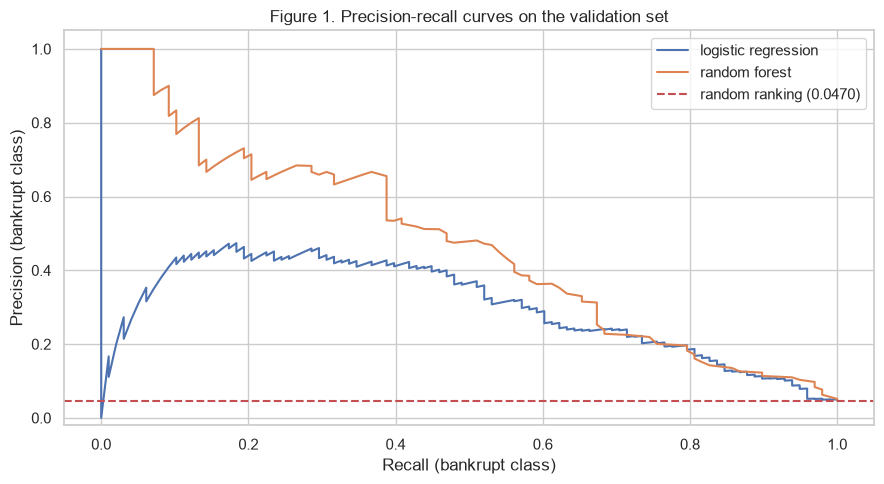

In [20]:
prec_logreg, rec_logreg, _ = precision_recall_curve(y_val, val_scores_logreg)
prec_forest, rec_forest, thresholds_forest = precision_recall_curve(y_val, val_scores_forest)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rec_logreg, prec_logreg, label="logistic regression")
ax.plot(rec_forest, prec_forest, label="random forest")
ax.axhline(y_val.mean(), color="C3", linestyle="--",
           label=f"random ranking ({y_val.mean():.4f})")
ax.set_title("Figure 1. Precision-recall curves on the validation set")
ax.set_xlabel("Recall (bankrupt class)")
ax.set_ylabel("Precision (bankrupt class)")
ax.set_ylim(-0.02, 1.05)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Interpretation:** The random forest curve runs above the logistic regression curve over most of the recall range, which matches its higher average precision. Both curves sit far above the dashed line at 0.0470, the precision a random ranking would achieve. Both also fall steeply, and no threshold delivers high precision and high recall at the same time. Every operating point is a trade between missed bankruptcies and false alarms. The threshold analysis below chooses that trade explicitly instead of leaving it to the default cut.


### Overfitting check

The forest's trees grow without a depth limit, `max_depth` stays at its sklearn default, so they can memorize the training data. To see how much of that happens here, I compute average precision on the training part and put it next to the validation values from above, for both learned models.

In [21]:
overfit_check = pd.DataFrame({
    "train": [
        average_precision_score(y_train, logreg_model.predict_proba(X_train)[:, 1]),
        average_precision_score(y_train, forest_model.predict_proba(X_train)[:, 1]),
    ],
    "validation": [
        average_precision_score(y_val, val_scores_logreg),
        average_precision_score(y_val, val_scores_forest),
    ],
}, index=["logistic regression", "random forest"])
overfit_check.round(4)

,train,validation
logistic regression,0.2811,0.3035
random forest,1.0000,0.4687


**Interpretation:** the forest ranks its training data perfectly, an average precision of 1.0000 on the training part against 0.4687 on validation. For trees without a depth limit this is the usual picture, each tree can memorize its training rows. Averaging 300 trees reduces the variance of a single tree, but it does not close the gap, and the validation value of 0.4687 is the number that counts. The gap is exactly why the model comparison and every threshold decision after it run on validation data the forest has never seen, and never on training data. The logistic regression shows no overfitting gap, its validation value (0.3035) even sits slightly above the training value (0.2811), which can happen with only 98 bankruptcies in the validation part. The check changes nothing about the selection, it confirms that training scores would have been worthless for it.

## Feature importances of the selected model

The forest reports how much each feature contributed to its splits. These importances show what the model uses, they are not a causal statement about bankruptcy. I map the anonymous column names to the readable definitions from the feature table and look at the ten most important ones.

In [22]:
feature_names = forest_model.named_steps["impute"].get_feature_names_out()
importances = pd.Series(forest_model.named_steps["model"].feature_importances_,
                        index=feature_names).sort_values(ascending=False)
top10 = importances.head(10)

print(f"The top 10 of {importances.size} features carry {top10.sum():.1%} of the total importance\n")
for name, value in top10.items():
    print(f"{value:.4f}  {describe_feature(name)}")

The top 10 of 108 features carry 29.6% of the total importance

0.0397  Attr27 is missing (profit on operating activities / financial expenses)
0.0396  Attr27: profit on operating activities / financial expenses
0.0343  Attr24: gross profit (in 3 years) / total assets
0.0311  Attr26: (net profit + depreciation) / total liabilities
0.0298  Attr16: (gross profit + depreciation) / total liabilities
0.0294  Attr34: operating expenses / total liabilities
0.0257  Attr46: (current assets - inventory) / short-term liabilities
0.0256  Attr13: (gross profit + depreciation) / sales
0.0203  Attr58: total costs / total sales
0.0201  Attr25: (equity - share capital) / total assets


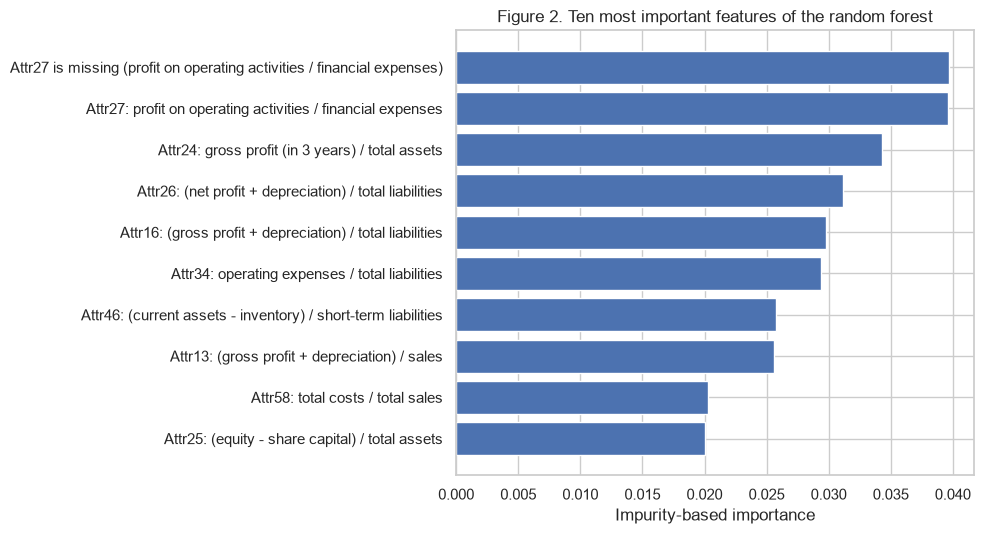

In [23]:
labels = [describe_feature(name) for name in top10.index]
labels = [text if len(text) <= 80 else text[:77] + "..." for text in labels]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(labels[::-1], top10.to_numpy()[::-1])
ax.set_title("Figure 2. Ten most important features of the random forest")
ax.set_xlabel("Impurity-based importance")
plt.tight_layout()
plt.show()

**Interpretation:** two things stand out. First, the most important input is not a ratio but a gap. The missing indicator of `Attr27` (0.0397) ranks first, directly followed by `Attr27` itself (0.0396). That supports the hedged reading from the data checks, the gaps themselves carry information. Why the value is absent, the source does not say. The ratio divides by financial expenses, so a company without financial expenses is one possible reason, but that stays a reading and not a finding. Second, no single feature dominates. The top 10 of the 108 inputs (the 64 financial indicators plus the 44 missing indicators from the imputer) carry only 29.6% of the total importance, so the forest spreads its decision over many inputs. The themes in the top 10 are familiar from the hand-written rule, profit or cost figures measured against total liabilities (`Attr26`, `Attr16`, `Attr34`), joined by a profit measured over three years (`Attr24`) and liquidity (`Attr46`). The importances describe what the forest uses on this dataset, they do not say that these ratios cause bankruptcy.

In [24]:
# the top feature is a gap, so I check how the gap relates to the label on the training data
def missing_vs_label(X, y, column):
    """Compare the bankruptcy rate with and without a value in one column.

    Returns one table row with the count of companies missing the value,
    the bankruptcy rate on both sides of the gap and how common the gap
    is in each class.
    """
    missing = X[column].isna()
    return {
        "companies without value": int(missing.sum()),
        "bankruptcy rate without value": y[missing].mean(),
        "bankruptcy rate with value": y[~missing].mean(),
        "gap share among bankrupt": missing[y == 1].mean(),
        "gap share among operating": missing[y == 0].mean(),
    }


# the importance rank of both indicators, for the interpretation below
for column in ["Attr27", "Attr37"]:
    name = f"missingindicator_{column}"
    rank = importances.index.get_loc(name) + 1
    print(f"{name}: importance {importances[name]:.4f}, rank {rank} of {importances.size}")

# Attr37 has the most gaps in the file and serves as the contrast
pd.DataFrame([missing_vs_label(X_train, y_train, "Attr27"),
              missing_vs_label(X_train, y_train, "Attr37")],
             index=["Attr27", "Attr37"]).round(4)

missingindicator_Attr27: importance 0.0397, rank 1 of 108
missingindicator_Attr37: importance 0.0007, rank 70 of 108


,companies without value,bankruptcy rate without value,bankruptcy rate with value,gap share among bankrupt,gap share among operating
Attr27,439,0.2278,0.0337,0.3378,0.0569
Attr37,2824,0.0475,0.0473,0.4527,0.4519


**Interpretation:** the gap in `Attr27` is a strong marker on its own. Among the 439 training companies without a value for this ratio, 22.78% went bankrupt, against 3.37% among the companies with a value, and a third of all bankrupt companies (33.78%) lack the ratio, against 5.69% of the operating ones. `Attr37` shows the opposite picture. It has by far the most gaps in the file, but the bankruptcy rate is the same with and without a value (4.75% against 4.73%), so on its own a missing value there tells little about the company. This backs the hedged reading from the data checks with a number and explains why the missing indicator of `Attr27` ranks first while the one of `Attr37` sits at rank 70 of 108 with an importance of 0.0007. The forest still uses that indicator in some splits, in combination with other inputs, but the near-equal rates show that it carries almost no signal by itself. How many gaps a column has and how much a gap tells are two different things.

## Threshold analysis on the validation set

The forest outputs a score between 0 and 1, and the screening needs decisions. I turn the scores into a three-band policy with two thresholds. Companies at or above the high threshold go to urgent review, companies between the two thresholds go on a watchlist, companies below the low threshold pass without action. I fix the two targets before computing anything. The urgent band has to be right at least half of the time (precision at least 0.50), because every urgent case costs analyst time immediately. The two flagged bands together have to catch at least 85% of the bankruptcies (recall at least 0.85), because a screening that misses a large part of the failures loses its purpose. Both targets are policy choices, not statistical constants, a real deployment would set them together with the analysts who work the bands. Both thresholds come from the forest's validation curve, the test set stays untouched.

In [25]:
# both targets are fixed in the markdown above, the curve arrays come from Figure 1
curve_precision = prec_forest[:-1]
curve_recall = rec_forest[:-1]

# lowest cut that meets the precision target, highest cut that still meets the recall target
urgent_idx = np.flatnonzero(curve_precision >= 0.50).min()
watch_idx = np.flatnonzero(curve_recall >= 0.85).max()
t_urgent = thresholds_forest[urgent_idx]
t_watch = thresholds_forest[watch_idx]

print(f"Urgent review threshold (precision >= 0.50): {t_urgent:.3f}")
print(f"Watchlist threshold (recall >= 0.85): {t_watch:.3f}")
print(f"Recall at the urgent threshold: {curve_recall[urgent_idx]:.4f}")
print(f"Precision at the watchlist threshold: {curve_precision[watch_idx]:.4f}")

# the bands use the unrounded thresholds, the rounded values above are for reading only
print(f"Unrounded thresholds used for the bands: urgent {float(t_urgent)!r}, watchlist {float(t_watch)!r}")
print(f"Validation companies exactly at the watchlist threshold: {int((val_scores_forest == t_watch).sum())}")

Urgent review threshold (precision >= 0.50): 0.160
Watchlist threshold (recall >= 0.85): 0.047
Recall at the urgent threshold: 0.4694
Precision at the watchlist threshold: 0.1353
Unrounded thresholds used for the bands: urgent 0.16, watchlist 0.04666666666666667
Validation companies exactly at the watchlist threshold: 53


The precision target puts the urgent threshold at a score of 0.160, and this cut alone already catches 46.9% of the validation bankruptcies. The recall target pushes the watchlist threshold down to a score of 0.047, and a single cut there would only be right in 13.5% of its flags. The two bands therefore flag with very different levels of confidence, and Figure 3 shows where the two cuts sit on the curves. One detail matters for anyone who wants to apply the policy. The printed values are rounded, the band function below uses the unrounded thresholds, and the selected watchlist cut is 0.04666666666666667, approximately 0.04667, which is 14 of the 300 trees voting for bankruptcy. 53 validation companies share exactly this score, so any rounded cut above it, 0.04667 or 0.047, would drop all of them from the watchlist and miss the recall target.

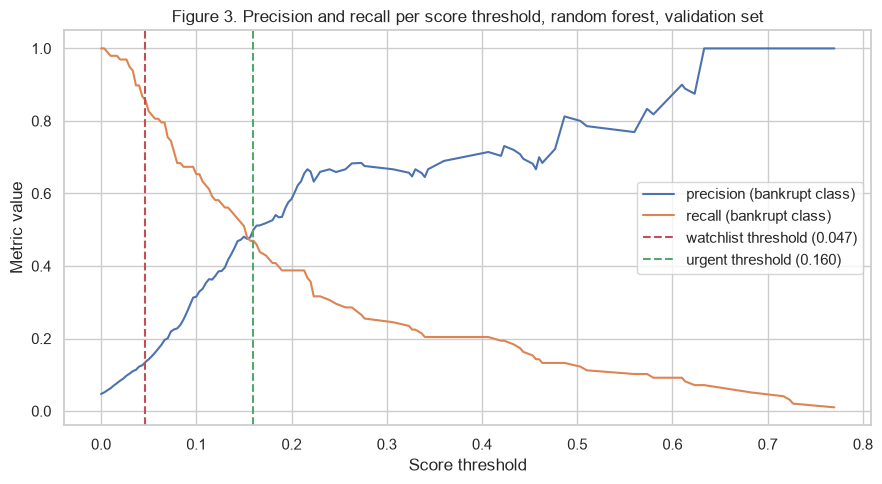

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds_forest, curve_precision, label="precision (bankrupt class)")
ax.plot(thresholds_forest, curve_recall, label="recall (bankrupt class)")
ax.axvline(t_watch, color="C3", linestyle="--", label=f"watchlist threshold ({t_watch:.3f})")
ax.axvline(t_urgent, color="C2", linestyle="--", label=f"urgent threshold ({t_urgent:.3f})")
ax.set_title("Figure 3. Precision and recall per score threshold, random forest, validation set")
ax.set_xlabel("Score threshold")
ax.set_ylabel("Metric value")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

**Interpretation:** the two curves cross almost exactly at the urgent threshold, at a score of 0.160 precision and recall both stand near 0.47 to 0.50. Left of the crossing the recall line climbs steeply toward 1.0 while precision falls toward the 4.7% base rate, and that is the region the watchlist threshold sits in. Right of the crossing precision improves in steps. It stays around 0.65 to 0.7 for scores between roughly 0.25 and 0.45, rises to about 0.8 near the default 0.5 cut and reaches 1.0 above a score of about 0.64, where only a handful of companies remain and the line jumps between values. That jumpiness matches the evaluation table above, at the default 0.5 cut only 15 validation companies score that high, so single companies move the ratio visibly. The forest also never scores any validation company above roughly 0.77, the curves simply end there.

In [27]:
def band_table(y_true, scores, t_watch, t_urgent):
    """Summarize the three policy bands for one data part.

    A company lands in urgent review from t_urgent upward, on the
    watchlist from t_watch upward and in no action below that. The table
    counts companies and bankruptcies per band and shows which share of
    all bankruptcies each band captures.
    """
    bands = pd.cut(scores, bins=[-np.inf, t_watch, t_urgent, np.inf],
                   labels=["no action", "watchlist", "urgent review"],
                   right=False)
    table = pd.DataFrame({"band": bands, "bankrupt": np.asarray(y_true)})
    summary = (table.groupby("band", observed=False)
               .agg(companies=("bankrupt", "size"), bankrupt=("bankrupt", "sum")))
    summary["share of companies"] = summary["companies"] / summary["companies"].sum()
    summary["bankruptcy rate in band"] = summary["bankrupt"] / summary["companies"]
    summary["share of all bankruptcies"] = summary["bankrupt"] / summary["bankrupt"].sum()
    return summary.iloc[::-1]


val_bands = band_table(y_val, val_scores_forest, t_watch, t_urgent)
val_bands.round(4)

,companies,bankrupt,share of companies,bankruptcy rate in band,share of all bankruptcies
band,,,,,
urgent review,92,46,0.0442,0.5000,0.4694
watchlist,529,38,0.2540,0.0718,0.3878
no action,1462,14,0.7019,0.0096,0.1429


**Interpretation:** the urgent band is small and dense, 92 companies and every second one of them really goes bankrupt. The watchlist is the cost of the recall target, 529 companies (a quarter of the validation set) with a bankruptcy rate of 7.2%, only modestly above the 4.7% base rate. The no action band is not risk free, 14 of the 98 bankruptcies land there. Together the flagged bands catch 85.7%, which meets the target, and pushing the 14 missed cases lower would widen the watchlist even further. Both thresholds are now frozen, the final evaluation applies them unchanged to the test set.

## Final evaluation on the test set

Everything is frozen now, the selected forest, the two thresholds and the band definitions. The test set has been touched by nothing so far, so this section shows once how the screening performs on companies that played no role in any decision. I compute the two ranking metrics next to their validation values, then I apply the frozen cuts through the same band function as above.

In [28]:
test_scores_forest = forest_model.predict_proba(X_test)[:, 1]

print(f"Average precision, validation: {average_precision_score(y_val, val_scores_forest):.4f}, "
      f"test: {average_precision_score(y_test, test_scores_forest):.4f}")
print(f"ROC-AUC, validation: {roc_auc_score(y_val, val_scores_forest):.4f}, "
      f"test: {roc_auc_score(y_test, test_scores_forest):.4f}")

Average precision, validation: 0.4687, test: 0.5108
ROC-AUC, validation: 0.8951, test: 0.8917


The ranking quality carries over. The test average precision (0.5108) even sits slightly above the validation value (0.4687), and ROC-AUC is nearly unchanged (0.8917 against 0.8951). Differences this small can come from sampling noise alone with only 98 and 99 bankruptcies per part, so nothing suggests that the selection was tuned to a lucky validation set.

In [29]:
test_bands = band_table(y_test, test_scores_forest, t_watch, t_urgent)
test_bands.round(4)

,companies,bankrupt,share of companies,bankruptcy rate in band,share of all bankruptcies
band,,,,,
urgent review,99,48,0.0475,0.4848,0.4848
watchlist,516,37,0.2476,0.0717,0.3737
no action,1469,14,0.7049,0.0095,0.1414


**Interpretation:** the frozen cuts transfer. The urgent band holds 99 test companies and 48 of them really go bankrupt, a rate of 48.5% against the 50.0% the band reached on validation. The precision target of 0.50 is therefore not met on the test set. With 99 companies in the band the estimate is uncertain, one company moves the rate by a percentage point, but two more hits would have been needed, so on this held-out sample the target was missed. The two flagged bands together catch 85 of the 99 test bankruptcies (85.9%), the recall target holds. The band shares are stable too, the watchlist takes 24.8% of the companies against 25.4% on validation, and the no action band keeps a residual rate just under 1% in both parts. For the screening story this is the important result, the policy chosen on validation behaves almost identically on companies that played no role in choosing it.

## Summary

In this notebook I trained models that predict from 64 financial statement indicators whether a Polish company goes bankrupt three years later, using 10,416 unique company records from the UCI bankruptcy dataset. A random forest won the comparison against a dummy baseline, a hand-written solvency rule and a logistic regression, selected on validation average precision (0.4687 against 0.3035 for the logistic regression). Because bankruptcies are rare, I turned the scores into a three-band operating policy instead of a single cut, and on the untouched test set the frozen thresholds put 99 companies into urgent review with a 48.5% bankruptcy rate, caught 85.9% of the test bankruptcies and reached an average precision of 0.5108. The most surprising finding was that the most important input of the forest is the missing indicator of `Attr27`, the gaps in the data carry signal of their own. The main challenges were the class imbalance (4.7% bankrupt), which ruled out accuracy as an informative metric, and the extreme ratio values that may come from near-zero denominators. What the model cannot promise is transfer beyond its source, the data covers Polish companies from 2000 to 2013, so any use on other markets or periods needs a re-validation.